# Simulación de escenarios de tráfico

En este cuaderno se continúa el flujo del cuadernos de Aprendzaje Automático. Parte del modelo ya entrenado de XGBoost: modelo_final, del conjunto de test: `df_test`, de la lista de `VARIABLES`, del `TARGET` y de la función `calcular_metricas`. 

La simulación se realiza sobre el conjunto de test (año 2025), por no haber intervendio en ninguna fase del entrenamiento. 

Para cada escenario se modifican las variables de entrada `intensidad` y `ocupacion` en las franjas horarias, se recalcula la carga con el modelo y se compara con el escenario base (E0).

## Configuración

In [18]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CARPETA_PREPROTRANS = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\resultados\\preprocesamiento-transformacion')
CARPETA_ENTRADA = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\modelo')
CARPETA_SALIDA   = Path(r'C:\\Users\\ElsaBlacoArmengod\\OneDrive - Educa Bidco\\Escritorio\\personal\\TFM\\resultados\\simulaciones')
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

# Reutilizado cuaderno aprendizaje automático
RUTA_DATASET_MODELO = CARPETA_PREPROTRANS / 'dataset_modelo.csv'

df = pd.read_csv(RUTA_DATASET_MODELO)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values(['id', 'fecha']).reset_index(drop=True)

VARIABLES = ['intensidad', 'ocupacion', 'hora_sin', 'hora_cos','dia_sin',  'dia_cos', 'mes_sin',  'mes_cos','es_laborable','es_verano','es_arterial','es_principal','es_secundaria']
TARGET = 'carga'

df = df.sort_values('fecha').reset_index(drop=True)

FECHA_CORTE_TEST = '2025-01-01'
df_test  = df[df['fecha'] >= FECHA_CORTE_TEST].copy()

def calcular_metricas(y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    mask = y_real > 1e-6                       # MAPE excluye cargas nulas
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Obtenemos el modelo seleccionado y entrenado en el cuaderno de aprendizaje automático
modelo_final = joblib.load(CARPETA_ENTRADA / 'modelo_xgb0.pkl')

print('Entorno cargado correctamente')
print(f'  Modelo final: {type(modelo_final).__name__}')
print(f'  Registros de test: {len(df_test):,}')
print(f'  Rango temporal test: {df_test["fecha"].min()} a {df_test["fecha"].max()}')
print(f'  Tipologías: {df_test["tipologia"].unique().tolist()}')
print(df_test.columns)


Entorno cargado correctamente
  Modelo final: XGBRegressor
  Registros de test: 416,153
  Rango temporal test: 2025-01-01 00:00:00 a 2025-12-31 23:45:00
  Tipologías: ['Residencial', 'Secundaria', 'Principal', 'Arterial']
Index(['fecha', 'id', 'tipologia', 'intensidad', 'ocupacion', 'hora_sin',
       'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'es_laborable',
       'es_verano', 'es_arterial', 'es_principal', 'es_secundaria', 'carga'],
      dtype='str')


## Definición de los escenarios

Cada escenario se define a partir de la franja horaria, del factor intensidad y del factor ocupacion. 

Las modificaciones se aplican únicamente a los **días laborables** (`es_laborable == 1`), por ser el teletrabajo y la entrada flexible medidas que afectan a los desplazamientos por motivos laborales.

Existen dos tipos de franjas horarias la de reducción y la de aumento. La de reducción corresponde a la franja punta matutina donde se espera obtener una menor carga viaria, entre las 7 y las 9 h. Por otro lado, la de aumento entre las 9 y las 11, que es la que absorbe los viajes desplazados por la flexibilidad horaria. 

In [19]:
# Franjas horarias
FRANJA_REDUCCION = [7, 8, 9]     
FRANJA_AUMENTO   = [10, 11] 

# Escenarios
ESCENARIOS_CARACTERISTICAS = {
    'E0': [], 

    # Teletrabajo moderado reducción del 10% en intensidad y ocupación
    'E1': [(FRANJA_REDUCCION, 0.90, 0.90)],

    # Teletrabajo intensivo reducción del 20% en intensidad y ocupación
    'E2': [(FRANJA_REDUCCION, 0.80, 0.80)],

    # Flexibilidad horaria
    'E3': [(FRANJA_REDUCCION, 0.95, 0.85),(FRANJA_AUMENTO, 1.03, 1.08)],

    # Teletrabajo moderado + Flexibilidad horaria
    'E4': [(FRANJA_REDUCCION, 0.85, 0.75),(FRANJA_AUMENTO,   1.03, 1.08)],

    'E5': [(FRANJA_REDUCCION, 0.75, 0.65),(FRANJA_AUMENTO,   1.03, 1.08)]}

ESCENARIOS_NOMENCLATURA= {
    'E0': 'Base',
    'E1': 'Teletrabajo moderado',
    'E2': 'Teletrabajo intensivo',
    'E3': 'Flexibilidad horaria',
    'E4': 'Teletrabajo moderado + Flexibilidad',
    'E5': 'Teletrabajo intensivo + Flexibilidad'}

escenarios_codigo = list(ESCENARIOS_NOMENCLATURA.keys()) 
escenarios_descripcion = list(ESCENARIOS_NOMENCLATURA.values())   
# Perfiles
if 'hora' not in df_test.columns:
    df_test['hora'] = df_test['fecha'].dt.hour
    
perfil_hpunta = df_test['hora'].isin(FRANJA_REDUCCION) & (df_test['es_laborable'] == 1)
perfil_diacompleto   = (df_test['es_laborable'] == 1)

perfil_reduccion  = df_test['hora'].isin(FRANJA_REDUCCION) & (df_test['es_laborable'] == 1)
perfil_aumento = df_test['hora'].isin(FRANJA_AUMENTO)   & (df_test['es_laborable'] == 1)

## Función simulación

Se diseña la función `funcion_escenario` que parte de una copia del conjunto de test, modifica la intensidad y la ocupación según las características definidas previamente par el escenario y devuelve la matriz de varibales para predecir.

In [20]:
def aplicar_escenario(df_base, reglas):
    df_simulacion = df_base.copy()
    for horas, f_int, f_ocu in reglas:
        registros_simulacion = df_simulacion['hora'].isin(horas) & (df_simulacion['es_laborable'] == 1)
        df_simulacion.loc[registros_simulacion, 'intensidad'] *= f_int
        df_simulacion.loc[registros_simulacion, 'ocupacion']  *= f_ocu
    return df_simulacion

## Predicción carga por cada escenario

Para cada escenario se genera el conjunto modificado y se predice la carga con elmodelo final, almacenánose la predicció en df_test con la etiqueta correspondient al escenario. 

In [21]:
predicciones_escenarios = {}
for esc, reglas in ESCENARIOS_CARACTERISTICAS.items():
    df_sim = aplicar_escenario(df_test, reglas)
    predicciones_escenarios[esc] = modelo_final.predict(df_sim[VARIABLES])
    df_test[f'carga_{esc}'] = predicciones_escenarios[esc]

print('Predicciones escenarios:', list(predicciones_escenarios.keys()))
print(f'Registros de test: {len(df_test):,}')

Predicciones escenarios: ['E0', 'E1', 'E2', 'E3', 'E4', 'E5']
Registros de test: 416,153


## Resultados

### Efectos por escenario

En primer lugar, se evalúa el efecto de cada medida se cuantifica como la variación de la carga media respecto al escenario base (E0). Se calcula sobre dos ámbitos:

- **Franja punta laborable:** momento donde actúa directamente la medida.
- **Día completo laborable:** para valorar si el efecto positivo de la hora punta se traduce en una mejora del conjunto del día o si se traslada a otras franjas.

Efecto simulaciones en franja punta días laborables
                           Escenario Carga media (%) Δ (pp) Δ (%) relativa
                                Base       40.099998    0.0            0.0
                Teletrabajo moderado           36.57  -3.53          -8.79
               Teletrabajo intensivo       32.860001  -7.23     -18.040001
                Flexibilidad horaria           37.66  -2.44          -6.08
 Teletrabajo moderado + Flexibilidad       34.130001  -5.97         -14.89
Teletrabajo intensivo + Flexibilidad           30.35  -9.75         -24.32
Efecto simulaciones en día completo laborable
                           Escenario Carga media (%) Δ (pp) Δ (%) relativa
                                Base       27.360001    0.0            0.0
                Teletrabajo moderado           26.91  -0.44          -1.62
               Teletrabajo intensivo       26.450001  -0.91          -3.32
                Flexibilidad horaria       27.139999  -0.22           -0.8
 T

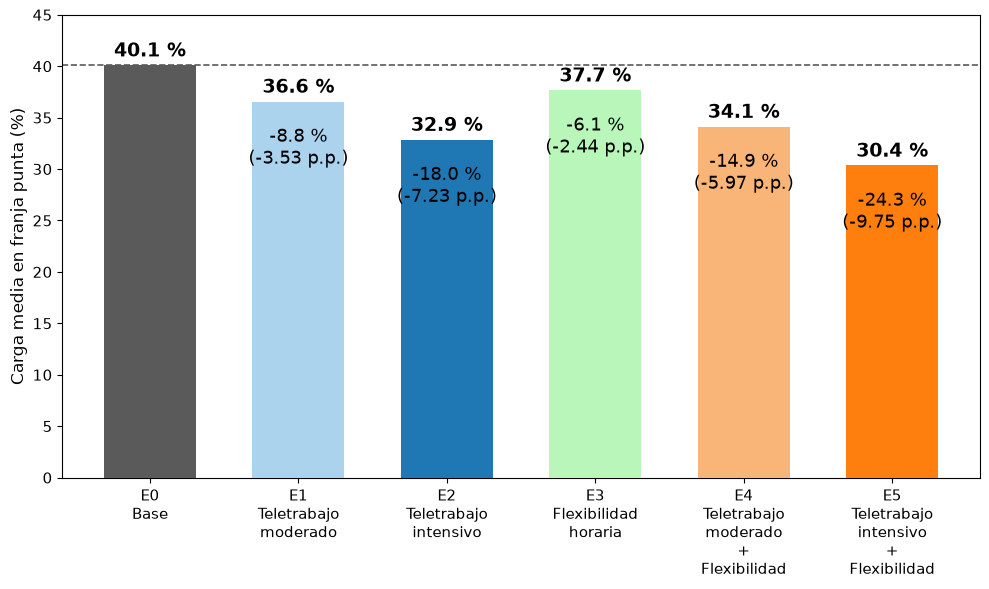

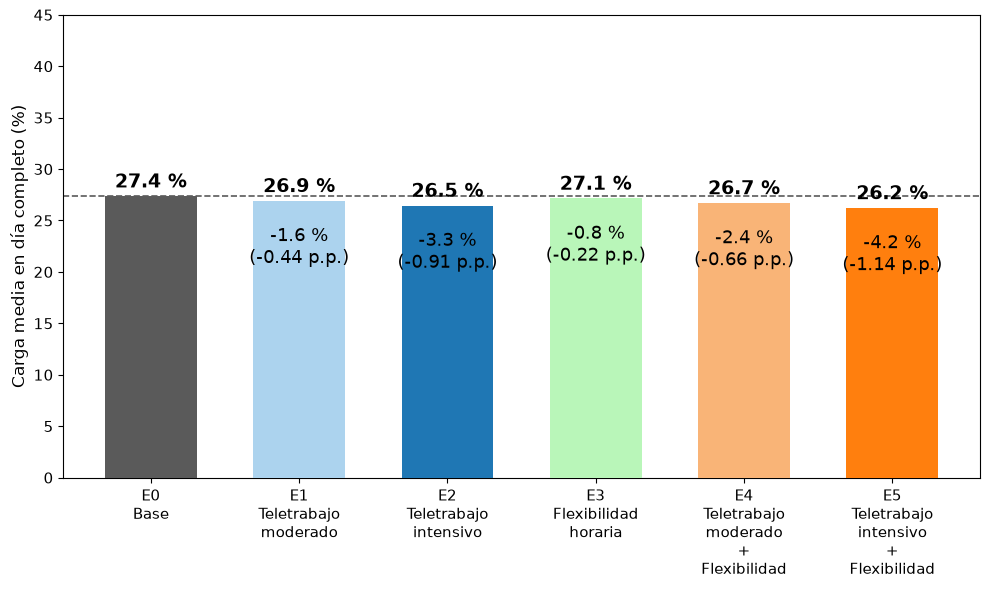

In [22]:
def resumen_efecto(perfil):
    base = df_test.loc[perfil, 'carga_E0'].mean()
    filas = {}
    for esc in ESCENARIOS_CARACTERISTICAS:
        media = df_test.loc[perfil, f'carga_{esc}'].mean()
        filas[esc] = {
            'Escenario': ESCENARIOS_NOMENCLATURA[esc],
            'Carga media (%)': round(media, 2),
            'Δ (pp)':          round(media - base, 2),           
            'Δ (%) relativa':  round(100 * (media - base) / base, 2)}
    return pd.DataFrame(filas).T

tabla_punta = resumen_efecto(perfil_hpunta)
tabla_dia   = resumen_efecto(perfil_diacompleto)

print('Efecto simulaciones en franja punta días laborables')
print(tabla_punta.to_string(index=False))
print('Efecto simulaciones en día completo laborable')
print(tabla_dia.to_string(index=False))

tabla_punta.to_csv(CARPETA_SALIDA / 'simulacion_efecto_franja_punta_lab.csv', index=False)
tabla_dia.to_csv(CARPETA_SALIDA / 'simulacion_efecto_dia_completo_lab.csv', index=False)

# Graficos
configuraciones = [
    (tabla_punta, 'Carga media en franja punta (%)', 'grafico_reduccion_hora_punta_lab.png'),
    (tabla_dia,   'Carga media en día completo (%)',  'grafico_reduccion_dia_completo_lab.png')]

for tabla, titulo_eje, nombre_grafico in configuraciones:
    carga     = tabla['Carga media (%)'].astype(float).tolist()
    delta_pp  = tabla['Δ (pp)'].astype(float).tolist()
    delta_rel = tabla['Δ (%) relativa'].astype(float).tolist()
    base      = carga[0]

    nombres = [ESCENARIOS_NOMENCLATURA[e].replace(' + ', '\n+ ').replace(' ', '\n') for e in escenarios_codigo]

    fig, ax = plt.subplots(figsize=(10, 6))
    colores = ['#5a5a5a', "#acd3ee", '#1f77b4', "#b9f6b9", "#f9b477", "#ff7f0e"]
    barras = ax.bar(range(len(escenarios_codigo)), carga, color=colores, width=0.62, zorder=3)

    ax.axhline(base, color='#5a5a5a', linestyle='--', linewidth=1.2, zorder=2)
    
    for i, b in enumerate(barras):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4, f'{carga[i]:.1f} %',
                ha='center', va='bottom', fontsize=14, fontweight='bold')
        if i > 0:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()-2.4,
                    f'{delta_rel[i]:.1f} %\n({delta_pp[i]:.2f} p.p.)', ha='center', va='top', fontsize=13, color='black')

    ax.set_xticks(range(len(escenarios_codigo)))
    ax.set_xticklabels([f'{e}\n{n}' for e, n in zip(escenarios_codigo, nombres)], fontsize=11)
    ax.set_ylabel(titulo_eje, fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_ylim(0, 45)
    plt.tight_layout()
    fig.savefig(CARPETA_SALIDA / nombre_grafico, dpi=150, bbox_inches='tight')
    plt.show()

### Eecto flexibilidad horaria en la franja punta y posterior de días laborables

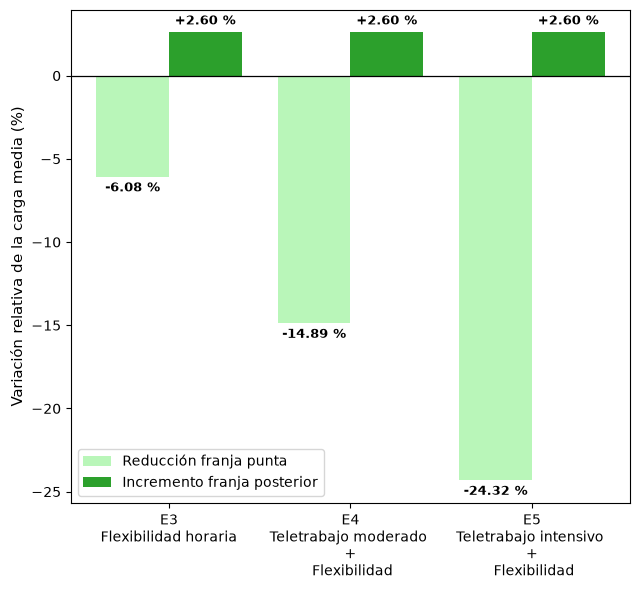

In [23]:
base_red = df_test.loc[perfil_reduccion,  'carga_E0'].mean()
base_aum = df_test.loc[perfil_aumento, 'carga_E0'].mean()

escs_flex = ['E3', 'E4', 'E5']  # escenarios con flexibilidad
desc = [100*(df_test.loc[perfil_reduccion,  f'carga_{e}'].mean() - base_red)/base_red for e in escs_flex]
abso = [100*(df_test.loc[perfil_aumento, f'carga_{e}'].mean() - base_aum )/base_aum  for e in escs_flex]

fig, ax = plt.subplots(figsize=(6.5, 6))
x = np.arange(len(escs_flex)); w = 0.4
b1 = ax.bar(x - w/2, desc, w, label='Reducción franja punta',    color='#b9f6b9')
b2 = ax.bar(x + w/2, abso, w, label='Incremento franja posterior', color="#2ca02c")
ax.axhline(0, color='black', linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"{e}\n" + ESCENARIOS_NOMENCLATURA[e].replace('+', '\n+\n') for e in escs_flex], fontsize=10)
ax.set_ylabel('Variación relativa de la carga media (%)', fontsize=11)
ax.legend(fontsize=10)
for barras in (b1, b2):
    for b in barras:
        yv = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, yv + (0.3 if yv>=0 else -0.3),f'{yv:+.2f} %', ha='center', va='bottom' if yv>=0 else 'top',fontsize=9, fontweight='bold')
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'grafico_h2_trasvase.png', dpi=150, bbox_inches='tight')
plt.show()

### Contraste escenarios combinados frente a individuales
La tercera hipótesis plantea que la aplicación conjunta de teletrabajo y flexibilidad produce un efecto **no aditivo**. Para contrastarla se compara la reducción observada en E4 con la suma de las reducciones individuales de E1 y E3 en la franja punta laborable. Una diferencia negativa (E4 reduce más que la suma) indica sinergia; una diferencia positiva indica solapamiento (efecto subaditivo).

In [24]:
def delta_pp(esc, mask):
    """Variación en puntos porcentuales respecto al base (E0) en el ámbito dado."""
    base = df_test.loc[mask, 'carga_E0'].mean()
    return df_test.loc[mask, f'carga_{esc}'].mean() - base

def fila_contraste(combinado, c1, c2, mask):
    """Construye la fila de contraste para un escenario combinado en un ámbito."""
    obs  = delta_pp(combinado, mask)
    suma = delta_pp(c1, mask) + delta_pp(c2, mask)
    return {
        'Efecto observado (pp)':  round(obs, 2),
        'Suma componentes (pp)':  round(suma, 2),
        'Interacción (pp)':       round(obs - suma, 2)}

# Tabla
filas = []
for combinado, c1, c2 in [('E4', 'E1', 'E3'), ('E5', 'E2', 'E3')]:
    p = fila_contraste(combinado, c1, c2, perfil_hpunta)
    d = fila_contraste(combinado, c1, c2, perfil_diacompleto)
    filas.append({
        'Escenario combinado':          f'{combinado} ({c1} + {c2})',
        'Punta · Efecto obs. (pp)':     p['Efecto observado (pp)'],
        'Punta · Suma comp. (pp)':      p['Suma componentes (pp)'],
        'Punta · Interacción (pp)':     p['Interacción (pp)'],
        'Día · Efecto obs. (pp)':       d['Efecto observado (pp)'],
        'Día · Suma comp. (pp)':        d['Suma componentes (pp)'],
        'Día · Interacción (pp)':       d['Interacción (pp)']})

tabla_contraste_pp = pd.DataFrame(filas)
tabla_contraste_pp.to_csv(CARPETA_SALIDA / 'contraste_interaccion_pp_punta_dia.csv', index=False)
print(tabla_contraste_pp.to_string(index=False))

Escenario combinado  Punta · Efecto obs. (pp)  Punta · Suma comp. (pp)  Punta · Interacción (pp)  Día · Efecto obs. (pp)  Día · Suma comp. (pp)  Día · Interacción (pp)
       E4 (E1 + E3)                     -5.97                    -5.96                     -0.00                   -0.66                  -0.66                   -0.00
       E5 (E2 + E3)                     -9.75                    -9.67                     -0.08                   -1.14                  -1.13                   -0.01


El análisis de la carga media resume el efecto de cada medida en un único valor facilitando la interpretación, pero no informa sobre el efecto en los registros de mayor saturación, que son los que motivan las políticas de descongestión. Por lo que, el análisis se complementa a través del efecto de cada escenario sobre el percentil 90 de la carga en la franja punta

In [25]:
def resumen_percentiles(mask):
    base = df_test.loc[mask, 'carga_E0']
    filas = {}
    for esc in ESCENARIOS_CARACTERISTICAS:
        sim = df_test.loc[mask, f'carga_{esc}']
        filas[esc] = {
            'Escenario':   ESCENARIOS_NOMENCLATURA[esc],
            'Media':       round(sim.mean(), 2),
            'P90':         round(sim.quantile(0.90), 2),
            'Δ p.p. media': round((sim.mean()-base.mean()), 2),
            'Δ p.p. P90':   round((sim.quantile(0.90)-base.quantile(0.90)), 2),
        }
    return pd.DataFrame(filas).T

tabla_pctl = resumen_percentiles(perfil_hpunta)
print('Efecto sobre los percentiles altos en la franja de hora punta laborable')
print(tabla_pctl.to_string(index=False))
tabla_pctl.to_csv(CARPETA_SALIDA / 'simulacion_percentil90.csv', index=False)

Efecto sobre los percentiles altos en la franja de hora punta laborable
                           Escenario      Media    P90 Δ p.p. media Δ p.p. P90
                                Base  40.099998   61.2          0.0        0.0
                Teletrabajo moderado      36.57  56.25        -3.53      -4.95
               Teletrabajo intensivo  32.860001  51.53        -7.23      -9.67
                Flexibilidad horaria      37.66  57.85        -2.44      -3.35
 Teletrabajo moderado + Flexibilidad  34.130001  53.44        -5.97      -7.76
Teletrabajo intensivo + Flexibilidad      30.35  48.31        -9.75      -12.9


Adicionalmente, el impacto de las medidas de gestión de la demanda puede evaluarse a través de su capacidad para reducir la frecuencia de los episodios de congestión alta. Por lo que se cunatifica el porcentaje de registros de la franja punta cuya carga es superior al 50%.


FRECUENCIA DE CONGESTIÓN SEVERA (% registros en punta sobre umbral)
 Umbral (>%)  E0 (base)   E1  E1 Δ%    E2  E2 Δ%    E3  E3 Δ%    E4  E4 Δ%   E5  E5 Δ%
          50      38.91 26.8  -31.1 13.56  -65.1 31.67  -18.6 18.24  -53.1 7.33  -81.2


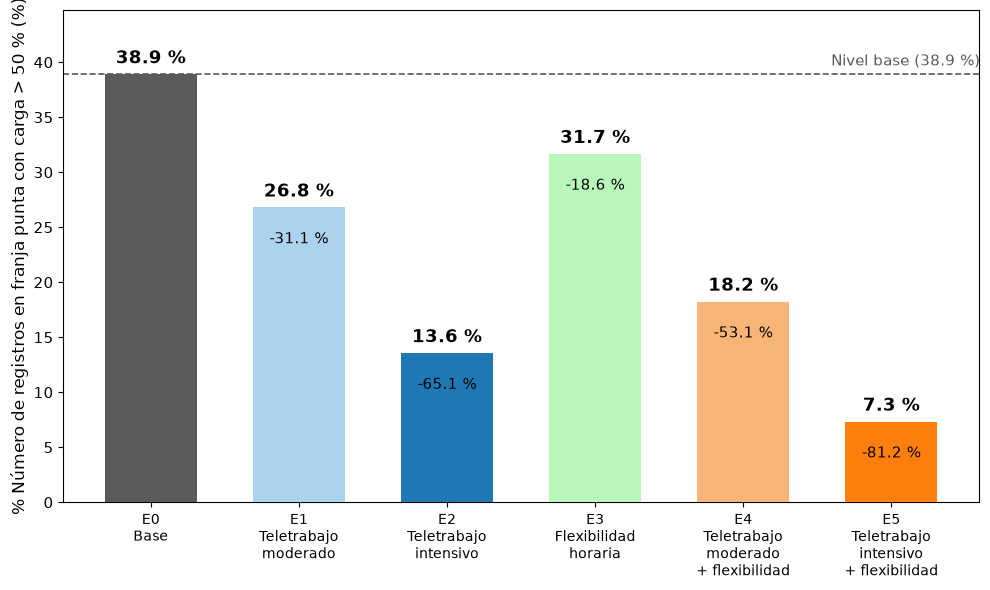

In [26]:
UMBRAL = 50

datos = (df_test.loc[perfil_hpunta, 'carga_E0'] > UMBRAL).mean() * 100
fila = {'Umbral (>%)': UMBRAL, 'E0 (base)': round(datos, 2)}
for esc in ['E1', 'E2', 'E3', 'E4', 'E5']:
    datos_sim = (df_test.loc[perfil_hpunta, f'carga_{esc}'] > UMBRAL).mean() * 100
    fila[esc] = round(datos_sim, 2)
    fila[f'{esc} Δ%'] = round(100*(datos_sim - datos)/datos, 1) if datos > 0 else np.nan

tabla_percentil = pd.DataFrame([fila])
print('FRECUENCIA DE CONGESTIÓN SEVERA (% registros en punta sobre umbral)')
print(tabla_percentil.to_string(index=False))
tabla_percentil.to_csv(CARPETA_SALIDA / 'simulacion_percentiles_congestion.csv', index=False)


escs = ['E0', 'E1', 'E2', 'E3', 'E4', 'E5']
nombres = ['Base', 'Teletrabajo\nmoderado', 'Teletrabajo\nintensivo','Flexibilidad\nhoraria', 'Teletrabajo\nmoderado\n+ flexibilidad','Teletrabajo\nintensivo\n+ flexibilidad']

# Frecuencia (%) de registros en punta que superan el 50% de carga
fila = tabla_percentil.iloc[0]
frec = [fila['E0 (base)']] + [fila[e] for e in ['E1','E2','E3','E4','E5']]
base = frec[0]
# reducción relativa respecto al base
delta_rel = [0.0] + [fila[f'{e} Δ%'] for e in ['E1','E2','E3','E4','E5']]

colores = ['#5a5a5a', '#acd3ee', '#1f77b4', '#b9f6b9', '#f9b477', '#ff7f0e']

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(range(len(escs)), frec, color=colores, width=0.62, zorder=3)

# línea del nivel base
ax.axhline(base, color='#5a5a5a', linestyle='--', linewidth=1.2, zorder=2)
ax.text(len(escs)-0.4, base+0.8, f'Nivel base ({base:.1f} %)',fontsize=11, color='#5a5a5a', ha='right')

for i, b in enumerate(barras):
    # valor absoluto encima
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.6, f'{frec[i]:.1f} %',ha='center', va='bottom', fontsize=13, fontweight='bold')
    # reducción relativa dentro de la barra
    if i > 0:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()-2.2,f'{delta_rel[i]:.1f} %', ha='center', va='top', fontsize=11, color='black')

ax.set_xticks(range(len(escs)))
ax.set_xticklabels([f'{e}\n{n}' for e, n in zip(escs, nombres)], fontsize=10)
ax.set_ylabel('% Número de registros en franja punta con carga > 50 % (%)', fontsize=12)
ax.set_ylim(0, base*1.15)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'simulacion_frecuencia_congestion.png', dpi=150, bbox_inches='tight')
plt.show()

### Efecto por tipología viaria

Se desglosa la variación porcentual de la carga por tipología, en la franja punta laborable, para identificar qué vías responden con mayor sensibilidad a cada medida (cuarto objetivo específico).

Para cada escenario se cuantifica la reducción relativa media de la carga respecto al escenario base en la franja de hora punta de los días laborales, diferenciando las cuatro tipologías. 

VARIACIÓN DE LA CARGA POR TIPOLOGÍA Y ESCENARIO (%) — franja punta laborable
               E1         E2    E3         E4         E5
Tipología                                               
Arterial    -7.62 -15.660000 -5.09 -12.690000 -20.299999
Principal   -9.88 -20.469999 -5.99 -16.299999 -27.530001
Residencial -7.64 -16.320000 -5.36 -13.550000 -22.639999
Secundaria  -9.91 -19.209999 -8.09 -16.799999 -26.040001


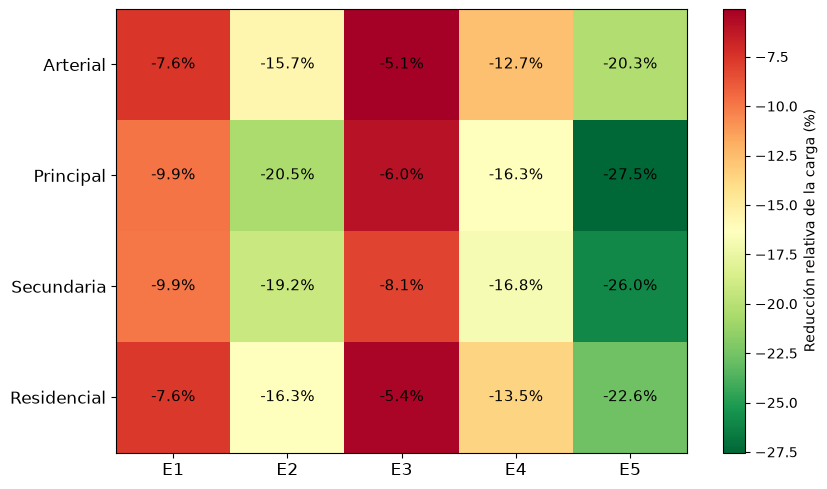

In [28]:
filas_tip = []
for tip, grupo in df_test[perfil_hpunta].groupby('tipologia'):
    base_tip = grupo['carga_E0'].mean()
    fila = {'Tipología': tip}
    for esc in ['E1', 'E2', 'E3', 'E4', 'E5']:
        media = grupo[f'carga_{esc}'].mean()
        fila[esc] = round(100 * (media - base_tip) / base_tip, 2)
    filas_tip.append(fila)

tabla_tip_esc = pd.DataFrame(filas_tip).set_index('Tipología')
print('VARIACIÓN DE LA CARGA POR TIPOLOGÍA Y ESCENARIO (%) — franja punta laborable')
print(tabla_tip_esc.to_string())
tabla_tip_esc.to_csv(CARPETA_SALIDA / 'simulacion_efecto_por_tipologia.csv')


# Visualizacion 
ORDEN_TIPOS = ['Arterial', 'Principal', 'Secundaria', 'Residencial']
tipos = [t for t in ORDEN_TIPOS if t in df_test['tipologia'].unique()]
escs = ['E1','E2','E3','E4','E5']
filas = {}
for tip in tipos:
    m = perfil_hpunta & (df_test['tipologia'] == tip)
    base_tip = df_test.loc[m, 'carga_E0'].mean()
    filas[tip] = [100*(df_test.loc[m, f'carga_{e}'].mean() - base_tip)/base_tip for e in escs]
tabla_tip_esc = pd.DataFrame(filas).T
tabla_tip_esc.columns = escs

# 2) Mapa de calor
M = tabla_tip_esc.values
tipos_lbl = list(tabla_tip_esc.index)
cols = list(tabla_tip_esc.columns)

fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(M, cmap='RdYlGn_r', aspect='auto', vmin=M.min(), vmax=M.max())
ax.set_xticks(range(len(cols)));  ax.set_xticklabels(cols, fontsize=12)
ax.set_yticks(range(len(tipos_lbl))); ax.set_yticklabels(tipos_lbl, fontsize=12)
for i in range(len(tipos_lbl)):
    for j in range(len(cols)):
        ax.text(j, i, f'{M[i,j]:.1f}%', ha='center', va='center', fontsize=11, color='black')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Reducción relativa de la carga (%)', fontsize=10)
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'heatmap_tipologia.png', dpi=150, bbox_inches='tight')
plt.show()

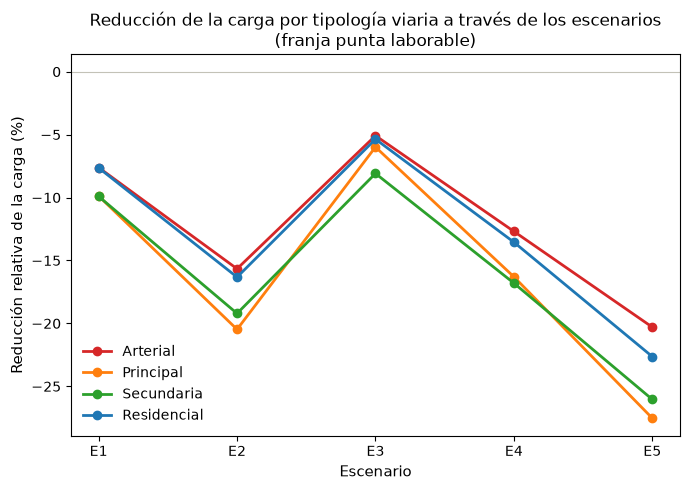

In [29]:
COLORES_TIPOLOGIAS = {
    'Arterial':    '#d62728',
    'Principal':   '#ff7f0e',
    'Secundaria':  '#2ca02c',
    'Residencial': '#1f77b4'}


fig, ax = plt.subplots(figsize=(7, 5))
for tip in tabla_tip_esc.index:
    ax.plot(tabla_tip_esc.columns, tabla_tip_esc.loc[tip],marker='o',color=COLORES_TIPOLOGIAS.get(tip),linewidth=2, markersize=6, label=tip)

ax.set_xlabel('Escenario', fontsize=11)
ax.set_ylabel('Reducción relativa de la carga (%)', fontsize=11)
ax.set_title('Reducción de la carga por tipología viaria a través de los escenarios\n(franja punta laborable)', fontsize=12)
ax.axhline(0, color='#c3c2b7', linewidth=0.8, zorder=0)
ax.legend(frameon=False, fontsize=10, loc='lower left')
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'lineas_tipologia_escenario.png', dpi=150, bbox_inches='tight')
plt.show()

EFECTO POR SENSOR EN TODOS LOS ESCENARIOS — franja punta laborable
Sensor   Tipología     E1         E2     E3         E4         E5
  5774    Arterial  -7.03 -14.710000  -4.26 -10.860000 -18.840000
  5777    Arterial  -6.57 -13.870000  -3.77 -11.050000 -17.209999
 10603    Arterial -10.00 -19.680000  -8.21 -17.780001 -26.940001
  4421   Principal  -9.74 -20.910000  -5.91 -16.600000 -28.299999
  4433   Principal -11.34 -22.959999  -6.23 -17.629999 -29.629999
  5711   Principal  -8.24 -16.770000  -5.78 -14.220000 -23.850000
  3469 Residencial  -6.47 -14.240000  -4.66 -11.850000 -20.260000
  4434 Residencial  -7.65 -17.270000  -5.60 -14.620000 -24.030001
 10604 Residencial  -8.67 -17.559999  -5.82 -14.350000 -23.840000
  4428  Secundaria  -8.20 -17.180000  -6.17 -14.610000 -23.100000
  4457  Secundaria -11.96 -21.160000 -10.29 -19.080000 -29.370001
  5778  Secundaria  -9.12 -19.160000  -7.37 -16.430000 -25.040001


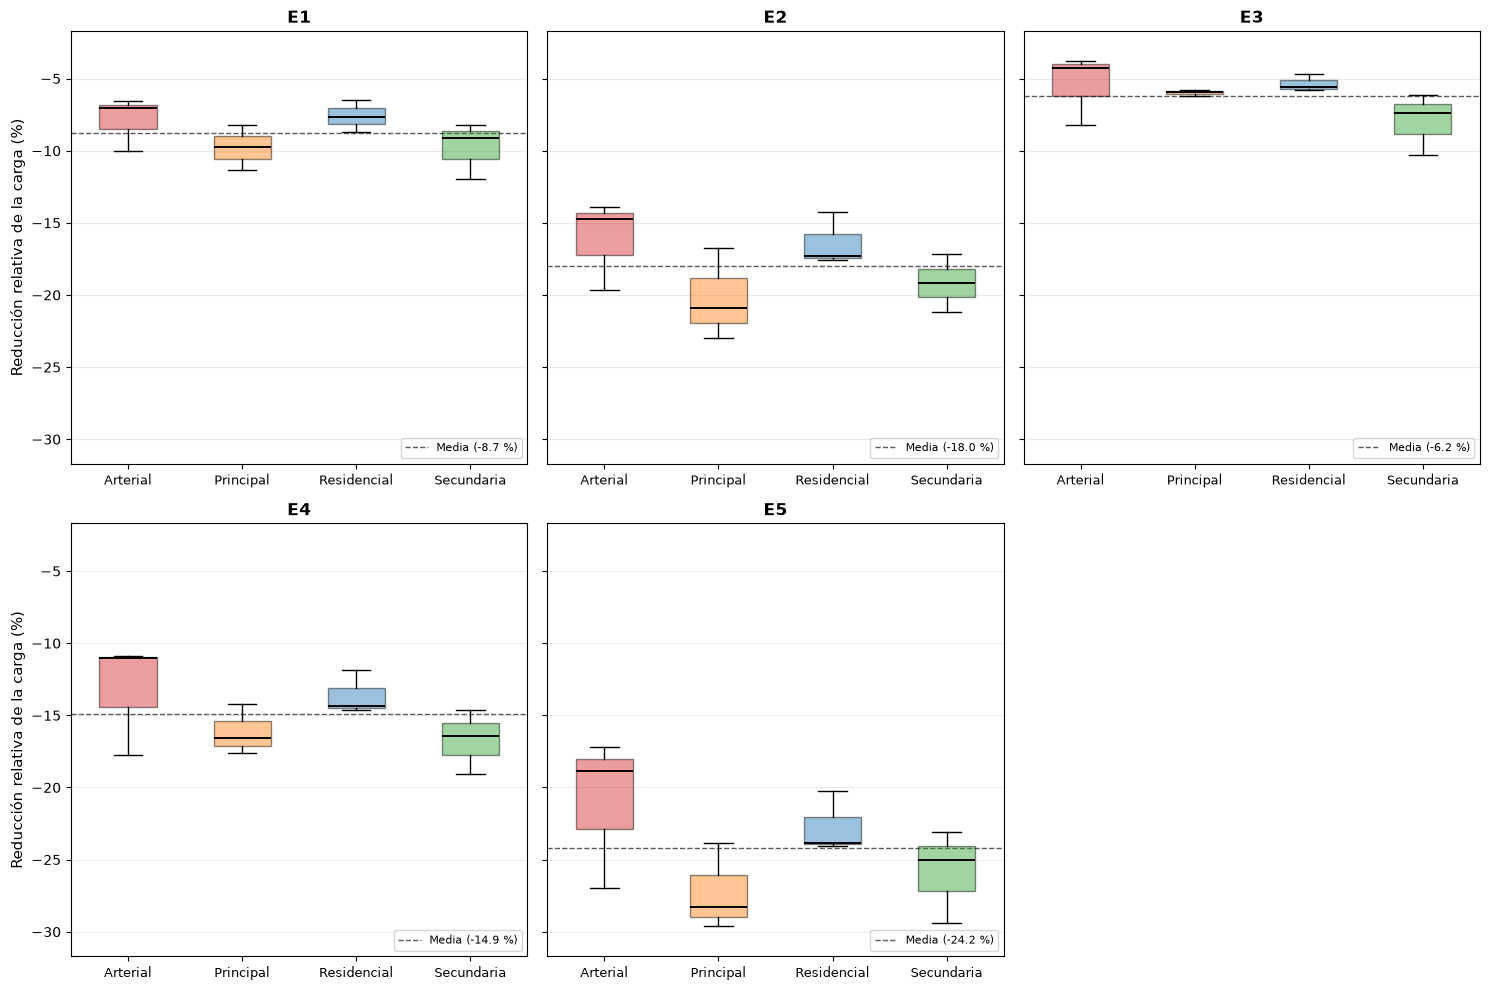

In [30]:
escenarios = ['E1', 'E2', 'E3', 'E4', 'E5']

filas_sensor = []
for (sensor, tip), grupo in df_test[perfil_hpunta].groupby(['id', 'tipologia']):
    base_s = grupo['carga_E0'].mean()
    if base_s > 1e-6:
        fila = {'Sensor': str(sensor), 'Tipología': tip}
        for esc in escenarios:
            fila[esc] = round(100 * (grupo[f'carga_{esc}'].mean() - base_s) / base_s, 2)
        filas_sensor.append(fila)

tabla_sensor = pd.DataFrame(filas_sensor).sort_values('Tipología')
tabla_sensor.to_csv(CARPETA_SALIDA / 'simulacion_efecto_por_sensor_todos.csv', index=False)
print('EFECTO POR SENSOR EN TODOS LOS ESCENARIOS — franja punta laborable')
print(tabla_sensor.to_string(index=False))

orden = sorted(tabla_sensor['Tipología'].unique())

ymin = tabla_sensor[escenarios].min().min()
ymax = tabla_sensor[escenarios].max().max()
margen = (ymax - ymin) * 0.08

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)
axes = axes.flatten()
for ax, esc in zip(axes, escenarios):
    datos = [tabla_sensor.loc[tabla_sensor['Tipología'] == t, esc] for t in orden]
    media_global = tabla_sensor[esc].mean()
    bp = ax.boxplot(datos, tick_labels=orden, showfliers=False, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.4), widths=0.5, zorder=2)
    for parche, t in zip(bp['boxes'], orden):
        parche.set_facecolor(COLORES_TIPOLOGIAS[t])
        parche.set_alpha(0.45)
    ax.axhline(media_global, color='#5a5a5a', linestyle='--', linewidth=1,
               label=f'Media ({media_global:.1f} %)', zorder=1)
    ax.set_title(esc, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='x', rotation=0, labelsize=9)

axes[0].set_ylabel('Reducción relativa de la carga (%)', fontsize=11)
axes[3].set_ylabel('Reducción relativa de la carga (%)', fontsize=11)
axes[0].set_ylim(ymin - margen, ymax + margen)

axes[5].axis('off')  # ocultar el sexto panel vacío

plt.tight_layout()
fig.savefig(CARPETA_SALIDA / 'simulacion_dispersion_sensores_todos.png', dpi=150, bbox_inches='tight')
plt.show()